Step1. Import Libraries

In [1]:
import numpy as np
import csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Step2. Load The Dataset

In [3]:
def load_data(filename):
    features = []
    labels = []
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        header = next(reader)          # skip header
        for row in reader:
            # row[0]=id, row[1]=diagnosis (M/B), rest are features
            diagnosis = 1.0 if row[1] == 'M' else 0.0
            feat = [float(x) for x in row[2:]]   # all numeric features
            features.append(feat)
            labels.append(diagnosis)
    return np.array(features), np.array(labels).reshape(-1, 1)

X, y = load_data('Cancer_Data.csv')
print(f"Data shape: X={X.shape}, y={y.shape}")

Data shape: X=(569, 30), y=(569, 1)


Step3. Train/ Test Split and Standardized

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert to float32 for numerical stability
X_train = X_train_scaled.astype(np.float32)
X_test  = X_test_scaled.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)

print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 455 samples, Test set: 114 samples


Step4.Neural Network Class

In [5]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        # He initialisation for ReLU
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # avoid overflow

    def relu(self, z):
        return np.maximum(0, z)

    def forward(self, X):
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def compute_loss(self, y_pred, y_true):
        # Binary Cross-Entropy
        m = y_true.shape[0]
        eps = 1e-8
        loss = - (1/m) * np.sum(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
        return loss

    def backward(self, X, y_true, y_pred):
        m = X.shape[0]
        # Gradient of output layer (dL/dz2)
        dz2 = y_pred - y_true                     # (m,1)
        dW2 = (1/m) * np.dot(self.a1.T, dz2)      # (hidden,1)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)

        # Gradient of hidden layer (dL/dz1)
        da1 = np.dot(dz2, self.W2.T)              # (m, hidden)
        dz1 = da1 * (self.z1 > 0).astype(float)   # ReLU derivative
        dW1 = (1/m) * np.dot(X.T, dz1)            # (input, hidden)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)

        return dW1, db1, dW2, db2

    def update_weights(self, dW1, db1, dW2, db2):
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train_step(self, X_batch, y_batch):
        # Forward
        y_pred = self.forward(X_batch)
        loss = self.compute_loss(y_pred, y_batch)
        # Backward
        dW1, db1, dW2, db2 = self.backward(X_batch, y_batch, y_pred)
        # Update
        self.update_weights(dW1, db1, dW2, db2)
        return loss

    def predict(self, X, threshold=0.5):
        probs = self.forward(X)
        return (probs >= threshold).astype(float)

    def accuracy(self, X, y_true):
        y_pred = self.predict(X)
        return np.mean(y_pred == y_true)

Step5. Training Loop

In [6]:
input_size  = X_train.shape[1]
hidden_size = 64          # can be tuned
output_size = 1
learning_rate = 0.01
epochs = 500
batch_size = 32

model = NeuralNetwork(input_size, hidden_size, output_size, learning_rate)

train_losses = []
test_losses = []
train_accs = []
test_accs = []

# number of batches per epoch
num_batches = int(np.ceil(X_train.shape[0] / batch_size))

for epoch in range(epochs):
    # Shuffle training data
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    epoch_loss = 0.0
    for batch_idx in range(num_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, X_train.shape[0])
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        loss = model.train_step(X_batch, y_batch)
        epoch_loss += loss * (end - start)  # weighted by batch size

    avg_train_loss = epoch_loss / X_train.shape[0]

    # Evaluate after each epoch (optional, we do it every 10 epochs for speed)
    if epoch % 10 == 0:
        train_acc = model.accuracy(X_train, y_train)
        test_acc = model.accuracy(X_test, y_test)
        # compute test loss
        y_test_pred = model.forward(X_test)
        test_loss = model.compute_loss(y_test_pred, y_test)
        train_losses.append(avg_train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

# Final evaluation
final_train_acc = model.accuracy(X_train, y_train)
final_test_acc = model.accuracy(X_test, y_test)
print(f"\nFinal Train Accuracy: {final_train_acc:.4f}")
print(f"Final Test Accuracy:  {final_test_acc:.4f}")

Epoch   0 | Train Loss: 0.9064 | Test Loss: 0.6028 | Train Acc: 0.6989 | Test Acc: 0.7281
Epoch  10 | Train Loss: 0.1801 | Test Loss: 0.1430 | Train Acc: 0.9560 | Test Acc: 0.9649
Epoch  20 | Train Loss: 0.1324 | Test Loss: 0.1034 | Train Acc: 0.9692 | Test Acc: 0.9649
Epoch  30 | Train Loss: 0.1114 | Test Loss: 0.0875 | Train Acc: 0.9736 | Test Acc: 0.9737
Epoch  40 | Train Loss: 0.0992 | Test Loss: 0.0796 | Train Acc: 0.9824 | Test Acc: 0.9737
Epoch  50 | Train Loss: 0.0905 | Test Loss: 0.0741 | Train Acc: 0.9868 | Test Acc: 0.9737
Epoch  60 | Train Loss: 0.0842 | Test Loss: 0.0708 | Train Acc: 0.9868 | Test Acc: 0.9737
Epoch  70 | Train Loss: 0.0790 | Test Loss: 0.0688 | Train Acc: 0.9868 | Test Acc: 0.9737
Epoch  80 | Train Loss: 0.0749 | Test Loss: 0.0671 | Train Acc: 0.9846 | Test Acc: 0.9737
Epoch  90 | Train Loss: 0.0714 | Test Loss: 0.0652 | Train Acc: 0.9868 | Test Acc: 0.9649
Epoch 100 | Train Loss: 0.0685 | Test Loss: 0.0639 | Train Acc: 0.9868 | Test Acc: 0.9649
Epoch 110 

Step6. Plot Training Curves

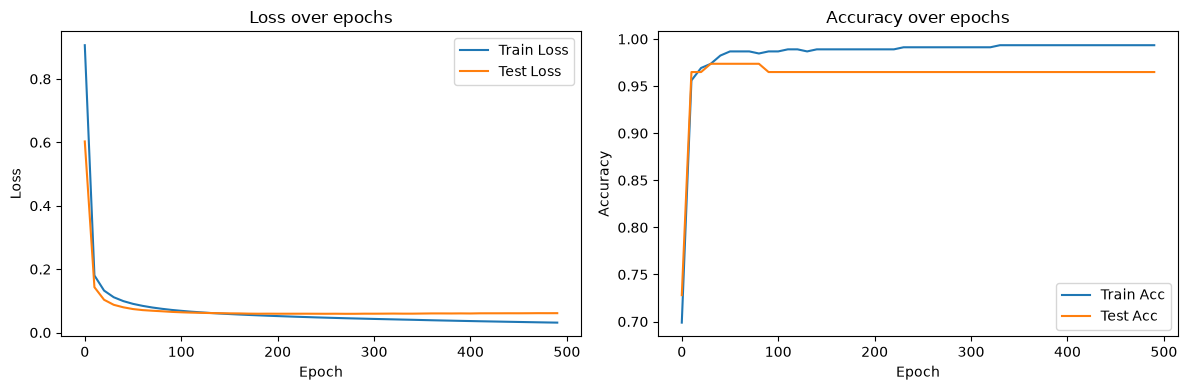

In [7]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(0, epochs, 10), train_losses, label='Train Loss')
plt.plot(range(0, epochs, 10), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over epochs')

plt.subplot(1,2,2)
plt.plot(range(0, epochs, 10), train_accs, label='Train Acc')
plt.plot(range(0, epochs, 10), test_accs, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.tight_layout()
plt.show()

Step7. Predictions On A Few Test Samples

In [8]:
sample_idx = 5
sample = X_test[sample_idx].reshape(1, -1)
true_label = y_test[sample_idx, 0]
prob = model.forward(sample)[0,0]
pred_label = 1 if prob >= 0.5 else 0
print(f"Sample {sample_idx}: True={int(true_label)}, Predicted={pred_label}, Probability={prob:.4f}")

Sample 5: True=1, Predicted=1, Probability=1.0000
